## Homework 2
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [1]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
import matplotlib.pyplot as plt
import numpy as np


In [2]:
%matplotlib inline

## Question 1

In [4]:
qc = QuantumCircuit(2)
qc.cx(0, 1)
qc.cx(1, 0)
qc.cx(0, 1)

qc.draw()


┌───┐     
q_0: ──■──┤ X ├──■──
     ┌─┴─┐└─┬─┘┌─┴─┐
q_1: ┤ X ├──■──┤ X ├
     └───┘     └───┘

\begin{aligned}
CX\, rCX\, CX
&=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{bmatrix}
\begin{bmatrix}
1&0&0&0\\
0&0&0&1\\
0&0&1&0\\
0&1&0&0
\end{bmatrix}
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{bmatrix}
\\
&=
\begin{bmatrix}
1&0&0&0\\
0&0&0&1\\
0&1&0&0\\
0&0&1&0
\end{bmatrix}
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{bmatrix}
\\
&=
\begin{bmatrix}
1&0&0&0\\
0&0&1&0\\
0&1&0&0\\
0&0&0&1
\end{bmatrix} = SWAP
\end{aligned}




Counts(ideal): {'00': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-07 14:31:30,855: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 14:31:31,533: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 14:31:33,236: Using instance: open-instance, plan: open


Counts: {'00': 126, '01': 2}


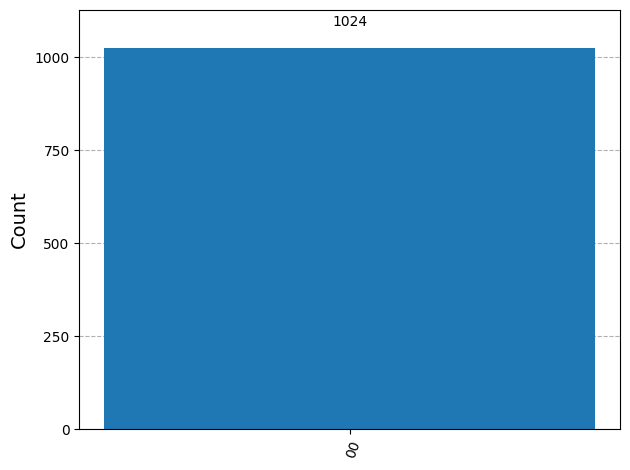

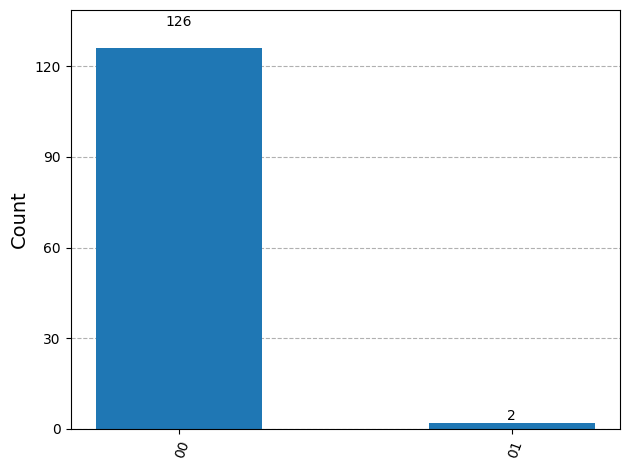

In [ ]:
#00 init

qc00 = QuantumCircuit(2)
qc00.cx(0, 1)
qc00.cx(1, 0)
qc00.cx(0, 1)

qc00.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc00], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc00)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);

Counts(ideal): {'10': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-07 14:32:23,114: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 14:32:23,654: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 14:32:24,846: Using instance: open-instance, plan: open


Counts: {'10': 120, '11': 2, '00': 4, '01': 2}


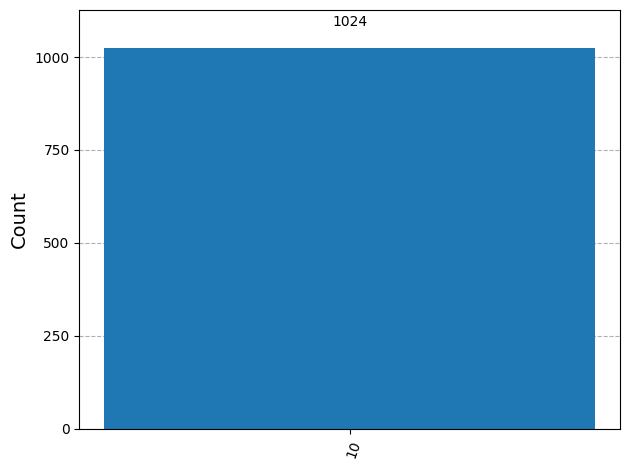

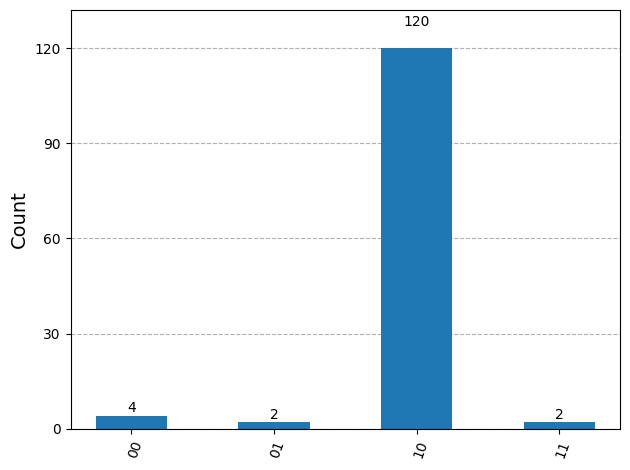

In [ ]:
#01 init

qc01 = QuantumCircuit(2)
qc01.x(0)
qc01.cx(0, 1)
qc01.cx(1, 0)
qc01.cx(0, 1)

qc01.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc01], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc01)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);

Counts(ideal): {'01': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-07 14:33:12,018: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 14:33:12,644: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 14:33:13,940: Using instance: open-instance, plan: open


Counts: {'01': 110, '00': 16, '10': 1, '11': 1}


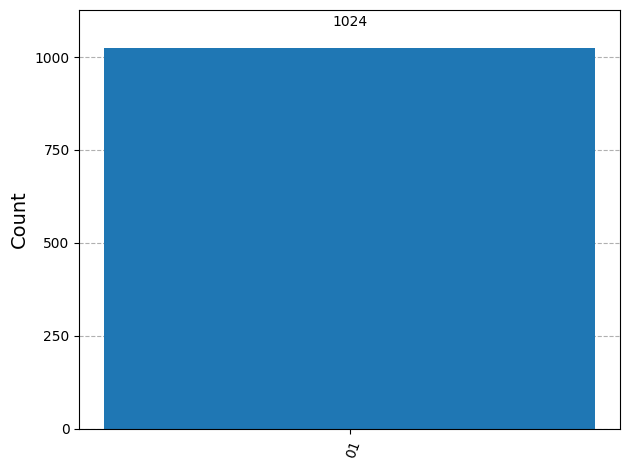

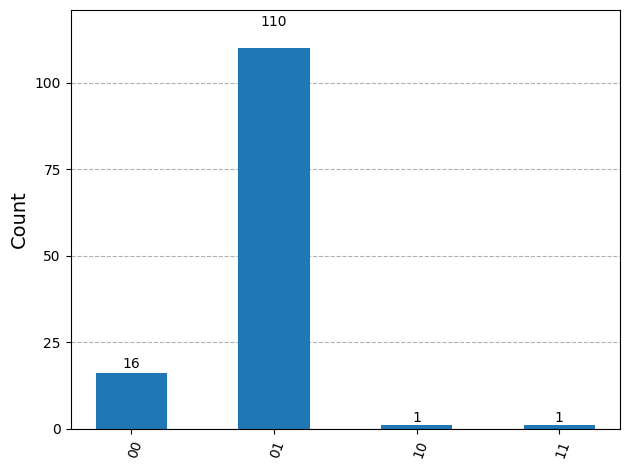

In [16]:
#10 init

qc10 = QuantumCircuit(2)
qc10.x(1)
qc10.cx(0, 1)
qc10.cx(1, 0)
qc10.cx(0, 1)

qc10.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc10], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc10)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);

Counts(ideal): {'11': 1024}


qiskit_runtime_service.__init__:WARNING:2026-02-07 14:34:27,743: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 14:34:28,384: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 14:34:30,310: Using instance: open-instance, plan: open


Counts: {'11': 107, '10': 14, '00': 5, '01': 2}


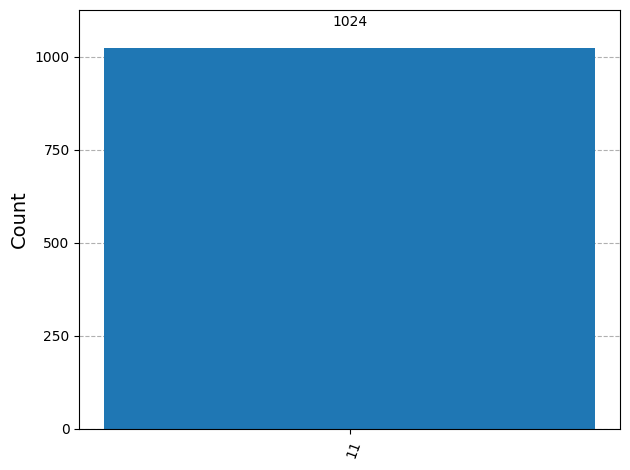

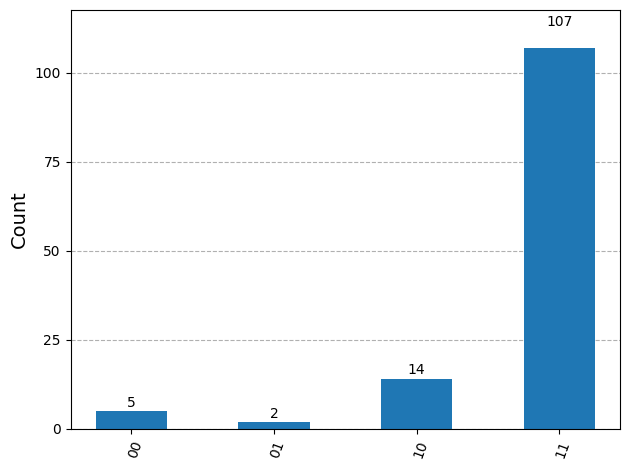

In [17]:
#11 init

qc11 = QuantumCircuit(2)
qc11.x(0)
qc11.x(1)
qc11.cx(0, 1)
qc11.cx(1, 0)
qc11.cx(0, 1)
qc11.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc11], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc11)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);

## Question 2

In [5]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.cx(0, 1)
qc.h(0)
qc.h(1)

qc.draw()

┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ H ├
     ├───┤┌─┴─┐├───┤
q_1: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘

\begin{aligned}
H \otimes H\, CX\, H \otimes H
&=
\frac{1}{2}
\begin{bmatrix}
1&1&1&1\\
1&-1&1&-1\\
1&1&-1&-1\\
1&-1&-1&1
\end{bmatrix}
\begin{bmatrix}
1&0&0&0\\
0&1&0&0\\
0&0&0&1\\
0&0&1&0
\end{bmatrix}
\frac{1}{2}
\begin{bmatrix}
1&1&1&1\\
1&-1&1&-1\\
1&1&-1&-1\\
1&-1&-1&1
\end{bmatrix}
\\
&=
\frac{1}{4}
\begin{bmatrix}
1&1&1&1\\
1&-1&-1&1\\
1&1&-1&-1\\
1&-1&1&-1
\end{bmatrix}
\begin{bmatrix}
1&1&1&1\\
1&-1&1&-1\\
1&1&-1&-1\\
1&-1&-1&1
\end{bmatrix}
\\
&=
\frac{1}{4}
\begin{bmatrix}
4&0&0&0\\
0&0&0&4\\
0&0&4&0\\
0&4&0&0
\end{bmatrix} 
= 
\begin{bmatrix}
1&0&0&0\\
0&0&0&1\\
0&0&1&0\\
0&1&0&0
\end{bmatrix} = rCX
\end{aligned}

Counts(ideal): {'00': 1024}


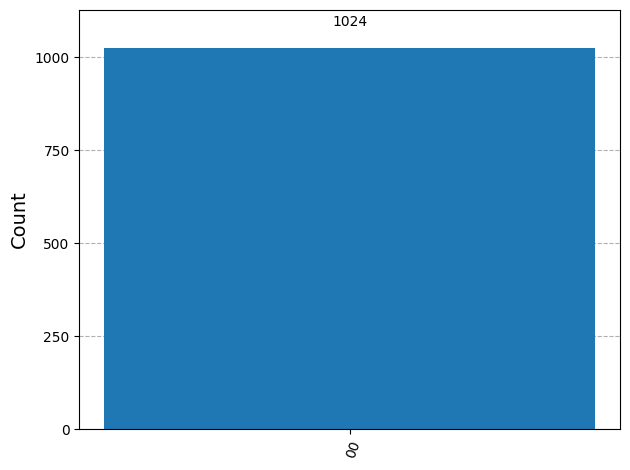

In [18]:
#00 init

qc00 = QuantumCircuit(2)
qc00.h(0)
qc00.h(1)
qc00.cx(0, 1)
qc00.h(0)
qc00.h(1)
qc00.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc00], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

Counts(ideal): {'01': 1024}


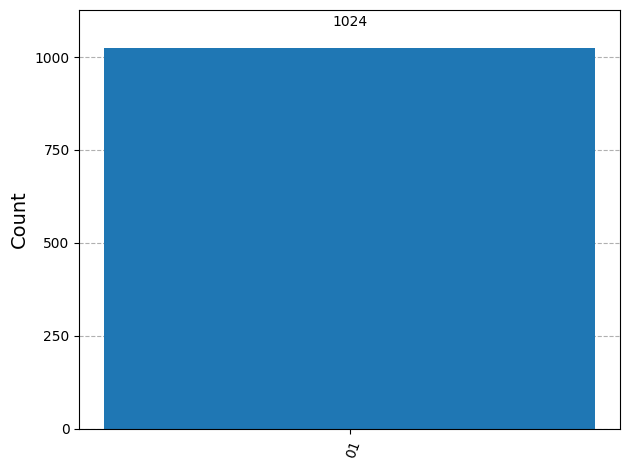

In [19]:
#01 init

qc01 = QuantumCircuit(2)
qc01.x(0)
qc01.h(0)
qc01.h(1)
qc01.cx(0, 1)
qc01.h(0)
qc01.h(1)
qc01.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc01], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

Counts(ideal): {'11': 1024}


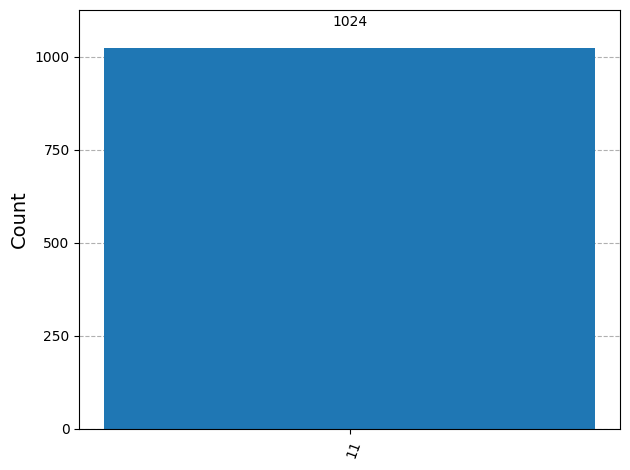

In [20]:
#10 init

qc10 = QuantumCircuit(2)
qc10.x(1)
qc10.h(0)
qc10.h(1)
qc10.cx(0, 1)
qc10.h(0)
qc10.h(1)
qc10.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc10], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

Counts(ideal): {'10': 1024}


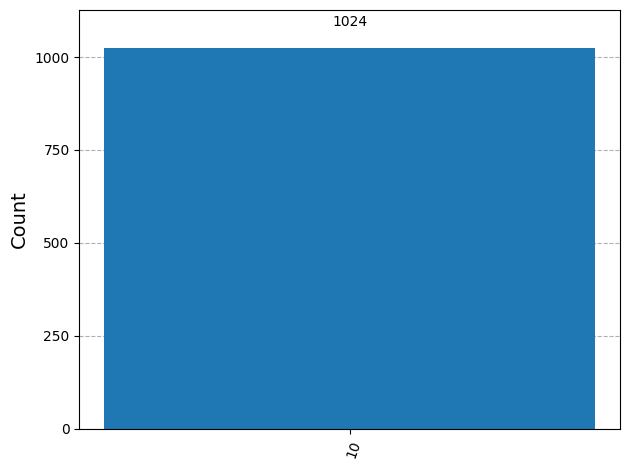

In [21]:
#11 init

qc11 = QuantumCircuit(2)
qc11.x(0)
qc11.x(1)
qc11.h(0)
qc11.h(1)
qc11.cx(0, 1)
qc11.h(0)
qc11.h(1)
qc11.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc11], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

## Question 3

Counts(ideal): {'00': 304, '11': 720}


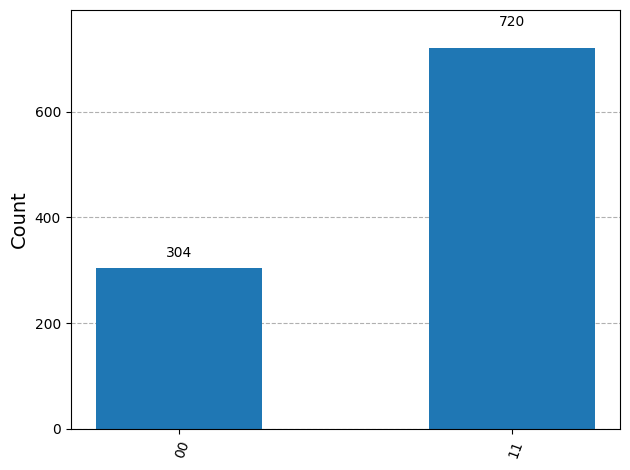

In [ ]:
alpha = np.sqrt(0.3)
beta = np.sqrt(0.7)

qc = QuantumCircuit(2)
qc.initialize([alpha, beta], 0)
qc.cx(0, 1)

# full measurement
qc.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);



Counts(ideal): {'1': 718, '0': 306}


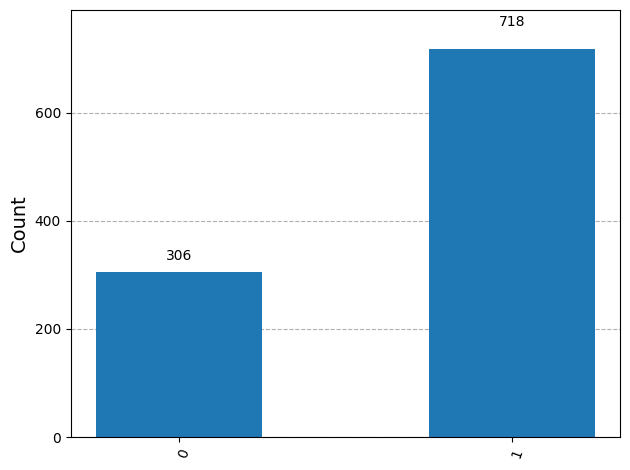

In [32]:
alpha = np.sqrt(0.3)
beta = np.sqrt(0.7)

qc = QuantumCircuit(2,1)
qc.initialize([alpha, beta], 0)
qc.cx(0, 1)

# partial measurement on second qubit
qc.measure(1,0)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);



$\ket{0}\ket{\psi} = \alpha\ket{00}+\beta\ket{01}$

$CX\ket{0}\ket{\psi} = \alpha\ket{00}+\beta\ket{11}$

Full Measurement:
$P(00) = |\alpha|^2, P(11) = |\beta|^2, P(01) = P(10) = 0$

Partial Measurement on q2:
$P(0) = |\alpha|^2, P(1) = |\beta|^2$

(Chose $\alpha=\sqrt{0.3}, \beta=\sqrt{0.7}$)

## Question 4

Counts(ideal): {'0001': 103, '0000': 265, '1111': 326, '0011': 54, '1110': 95, '1100': 60, '1001': 8, '0111': 23, '1000': 28, '1101': 15, '0110': 13, '0010': 22, '0100': 4, '0101': 2, '1011': 4, '1010': 2}


qiskit_runtime_service.__init__:WARNING:2026-02-07 16:34:23,262: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 16:34:23,970: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 16:34:25,372: Using instance: open-instance, plan: open


Counts: {'1111': 25, '1110': 15, '0000': 39, '0001': 18, '1100': 7, '1101': 3, '0010': 4, '0011': 6, '0110': 1, '0111': 2, '1000': 5, '1011': 1, '0100': 2}


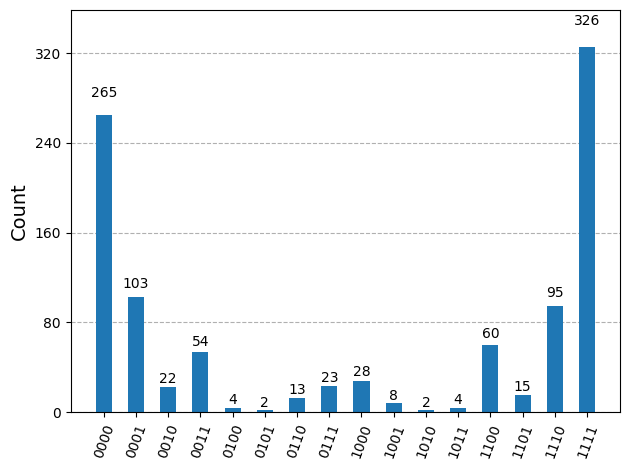

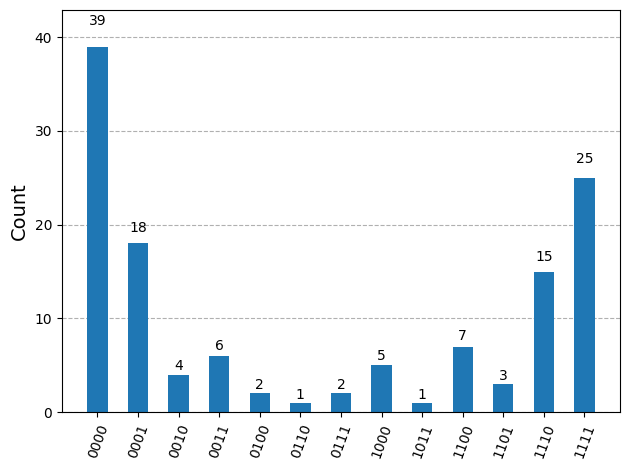

In [35]:
qc = QuantumCircuit(4)
qc.ry(np.pi/2, 0)
qc.ry(np.pi/3, 1)
qc.ry(np.pi/4, 2)
qc.ry(np.pi/6, 3)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.measure_all()

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);


Counts(ideal): {'10': 112, '11': 405, '00': 368, '01': 139}


qiskit_runtime_service.__init__:WARNING:2026-02-07 16:39:50,733: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-07 16:39:51,848: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-07 16:39:53,594: Using instance: open-instance, plan: open


Counts: {'10': 16, '11': 51, '00': 40, '01': 21}


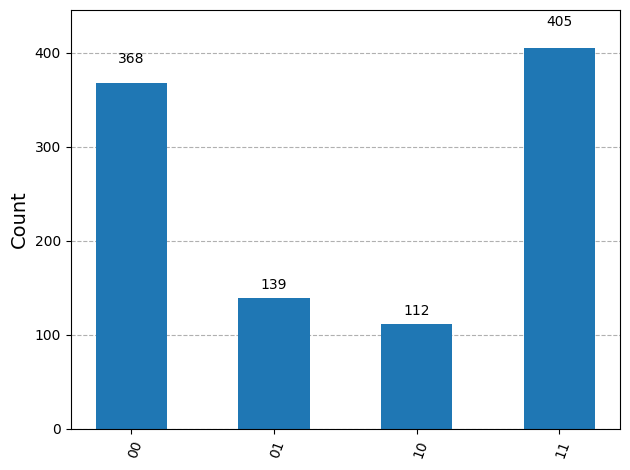

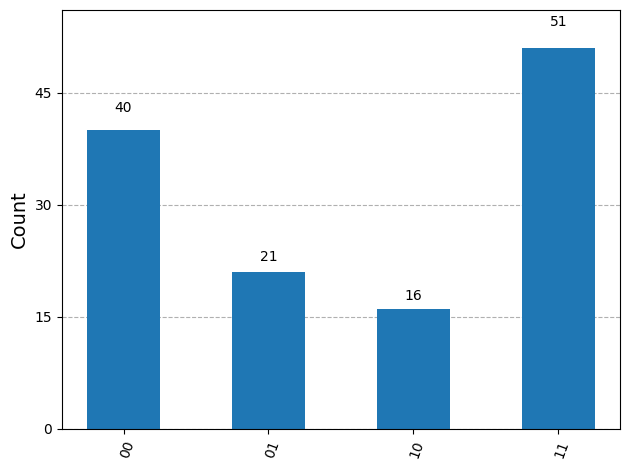

In [38]:
qc = QuantumCircuit(4,2)
qc.ry(np.pi/2, 0)
qc.ry(np.pi/3, 1)
qc.ry(np.pi/4, 2)
qc.ry(np.pi/6, 3)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)

qc.measure(0,0)
qc.measure(1,1)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(mode=backend)

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = sampler.run([isa_circuit], shots=128)

result_ideal = job.result()
counts_ideal = result_ideal[0].data.c.get_counts()
print('Counts:', counts_ideal)
plot_histogram(counts_ideal);


## Question 5

Counts(ideal): {'0': 1024}


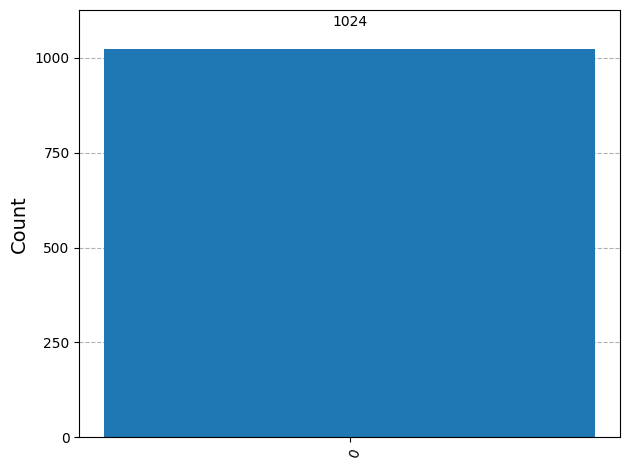

In [ ]:
# 00 init

qc = QuantumCircuit(2,1)
qc.cx(0, 1)
qc.measure(1,0)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);



Counts(ideal): {'1': 1024}


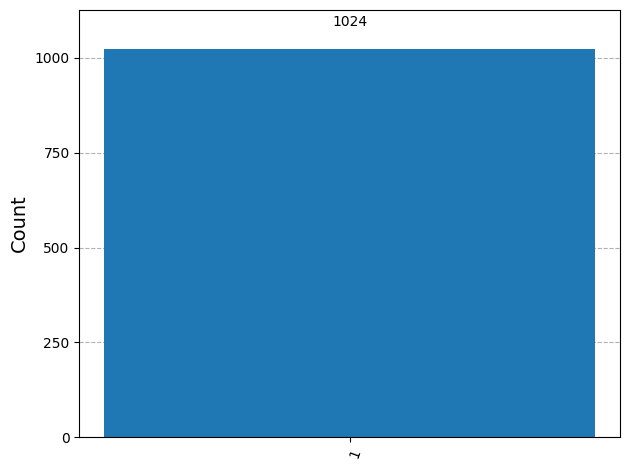

In [40]:
# 01 init

qc = QuantumCircuit(2,1)
qc.x(0)
qc.cx(0, 1)
qc.measure(1,0)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);



Counts(ideal): {'1': 1024}


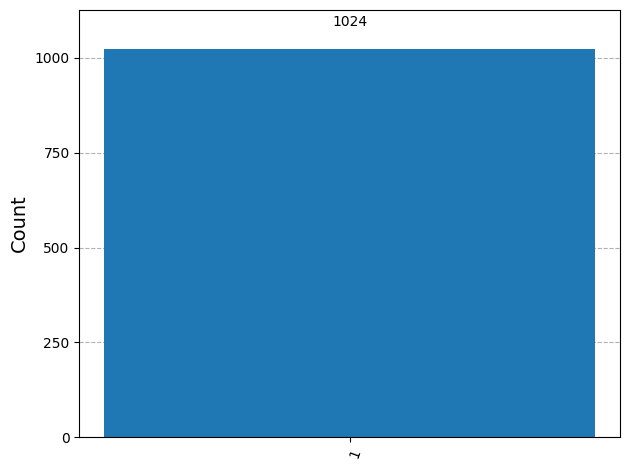

In [41]:
# 10 init

qc = QuantumCircuit(2,1)
qc.x(1)
qc.cx(0, 1)
qc.measure(1,0)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);



Counts(ideal): {'0': 1024}


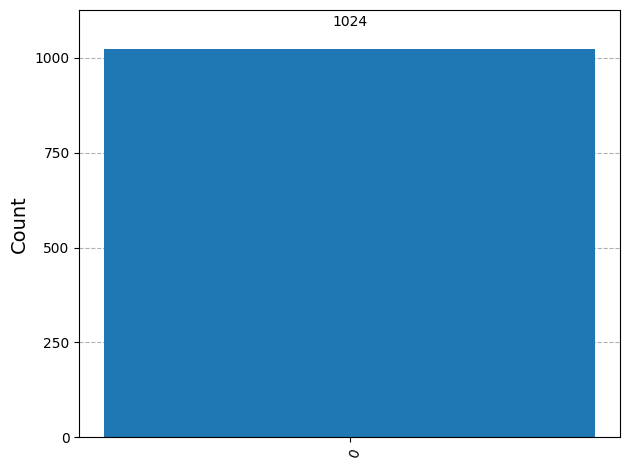

: 

In [ ]:
# 11 init

qc = QuantumCircuit(2,1)
qc.x(0)
qc.x(1)
qc.cx(0, 1)
qc.measure(1,0)

sampler = StatevectorSampler()

result = sampler.run([qc], shots=1024).result()
counts = result[0].data.c.get_counts()
print('Counts(ideal):', counts)
plot_histogram(counts);

